# DIAGNOVA — Chest X-Ray Multi-Label Classification
## DenseNet-121 | NIH ChestX-ray14 Dataset
**14 Classes | Sigmoid Output | AUC-ROC Metric**

## 1. Install & Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Load Metadata

In [2]:
# Paths — الـ path الصح بعد التجربة
DATA_DIR = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'
IMG_DIR  = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'

# Load metadata CSV
df = pd.read_csv(os.path.join(DATA_DIR, 'Data_Entry_2017.csv'))
print(f'Total images: {len(df)}')
print(df.head())
print(df.columns.tolist())

Total images: 112120
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.143

## 3. Explore & Visualize the Data

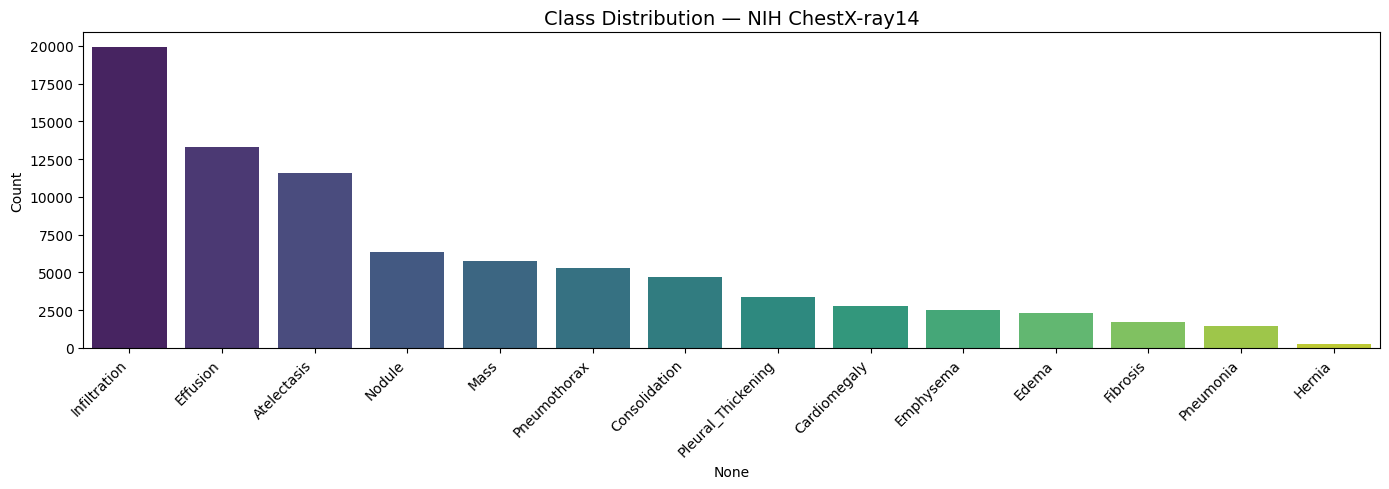

Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64


In [3]:
# All 14 classes
ALL_LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
    'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
    'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
    'Pleural_Thickening', 'Hernia'
]

# Create binary columns for each label
for label in ALL_LABELS:
    df[label] = df['Finding Labels'].apply(lambda x: 1 if label in x else 0)

# Class distribution
label_counts = df[ALL_LABELS].sum().sort_values(ascending=False)
plt.figure(figsize=(14, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Class Distribution — NIH ChestX-ray14', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png', dpi=150)
plt.show()
print(label_counts)

Labels per image distribution:
num_labels
0    60361
1    30963
2    14306
3     4856
4     1247
5      301
6       67
7       16
8        1
9        2
Name: count, dtype: int64


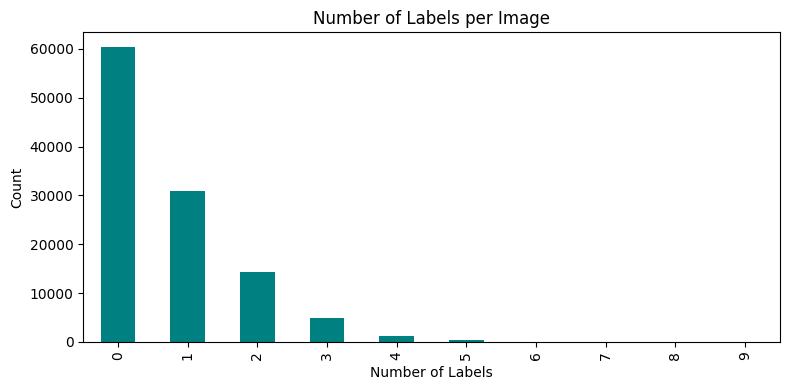

In [4]:
# Multi-label distribution
df['num_labels'] = df[ALL_LABELS].sum(axis=1)
print('Labels per image distribution:')
print(df['num_labels'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
df['num_labels'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('Number of Labels per Image')
plt.xlabel('Number of Labels')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Train/Val/Test Split (Patient-Level)

In [5]:
# Load official train/test split files
with open(os.path.join(DATA_DIR, 'train_val_list.txt'), 'r') as f:
    train_val_list = [x.strip() for x in f.readlines()]

with open(os.path.join(DATA_DIR, 'test_list.txt'), 'r') as f:
    test_list = [x.strip() for x in f.readlines()]

# Split train_val into train (85%) and val (15%)
np.random.seed(42)
np.random.shuffle(train_val_list)
split = int(0.85 * len(train_val_list))
train_list = train_val_list[:split]
val_list   = train_val_list[split:]

# Filter dataframe
train_df = df[df['Image Index'].isin(train_list)].reset_index(drop=True)
val_df   = df[df['Image Index'].isin(val_list)].reset_index(drop=True)
test_df  = df[df['Image Index'].isin(test_list)].reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 73545 | Val: 12979 | Test: 25596


## 5. Build Image Lookup Dictionary

In [6]:
# بناء image lookup مرة واحدة — أسرع بكتير من البحث كل مرة
print('Building image lookup dictionary...')
IMAGE_LOOKUP = {}
for folder in [f'images_{str(i).zfill(3)}' for i in range(1, 13)]:
    folder_path = os.path.join(IMG_DIR, folder, 'images')
    if os.path.exists(folder_path):
        for fname in os.listdir(folder_path):
            IMAGE_LOOKUP[fname] = os.path.join(folder_path, fname)

print(f'Total images indexed: {len(IMAGE_LOOKUP)}')

Building image lookup dictionary...
Total images indexed: 112120


## 6. Dataset & DataLoader

In [7]:
class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, labels, transform=None):
        self.df        = dataframe
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = IMAGE_LOOKUP.get(row['Image Index'])
        if img_path is None:
            raise FileNotFoundError(f"Image not found: {row['Image Index']}")

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.FloatTensor(row[self.labels].values.astype(float))
        return image, label


# Transforms
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = ChestXRayDataset(train_df, ALL_LABELS, train_transform)
val_dataset   = ChestXRayDataset(val_df,   ALL_LABELS, val_transform)
test_dataset  = ChestXRayDataset(test_df,  ALL_LABELS, val_transform)

# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 2299 | Val batches: 406 | Test batches: 800


## 7. Model — DenseNet-121

In [8]:
class DenseNet121_ChestXRay(nn.Module):
    def __init__(self, num_classes=14):
        super(DenseNet121_ChestXRay, self).__init__()

        # Load pretrained DenseNet-121
        self.densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

        # Replace classifier
        in_features = self.densenet.classifier.in_features  # 1024
        self.densenet.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.densenet(x)  # Raw logits — BCEWithLogitsLoss handles sigmoid


model = DenseNet121_ChestXRay(num_classes=14)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

Total params:     6,968,206
Trainable params: 6,968,206


## 8. Loss, Optimizer & Scheduler

In [9]:
# Compute positive weights for class imbalance
pos_counts  = train_df[ALL_LABELS].sum()
neg_counts  = len(train_df) - pos_counts
pos_weights = torch.FloatTensor((neg_counts / pos_counts).values).to(device)
print('Positive weights (for BCEWithLogitsLoss):')
for label, w in zip(ALL_LABELS, pos_weights.cpu()):
    print(f'  {label}: {w:.2f}')

# Loss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

Positive weights (for BCEWithLogitsLoss):
  Atelectasis: 9.40
  Cardiomegaly: 49.34
  Effusion: 8.94
  Infiltration: 5.28
  Mass: 20.29
  Nodule: 17.43
  Pneumonia: 98.12
  Pneumothorax: 32.08
  Consolidation: 29.49
  Edema: 61.43
  Emphysema: 60.54
  Fibrosis: 68.12
  Pleural_Thickening: 37.44
  Hernia: 622.26


## 9. Training Loop

In [10]:
def compute_auc(labels, outputs):
    aucs = []
    for i in range(labels.shape[1]):
        if labels[:, i].sum() > 0:
            try:
                auc = roc_auc_score(labels[:, i], outputs[:, i])
                aucs.append(auc)
            except:
                pass
    return np.mean(aucs) if aucs else 0.0


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    all_labels, all_outputs = [], []

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_labels.append(labels.cpu().detach().numpy())
        all_outputs.append(torch.sigmoid(outputs).cpu().detach().numpy())

        if (batch_idx + 1) % 100 == 0:
            print(f'  Batch [{batch_idx+1}/{len(loader)}] Loss: {loss.item():.4f}')

    all_labels  = np.concatenate(all_labels)
    all_outputs = np.concatenate(all_outputs)
    return total_loss / len(loader), compute_auc(all_labels, all_outputs)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_labels, all_outputs = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            all_labels.append(labels.cpu().numpy())
            all_outputs.append(torch.sigmoid(outputs).cpu().numpy())

    all_labels  = np.concatenate(all_labels)
    all_outputs = np.concatenate(all_outputs)
    return total_loss / len(loader), compute_auc(all_labels, all_outputs), all_labels, all_outputs

In [11]:
NUM_EPOCHS   = 10
best_val_auc = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}

print('=' * 60)
print('Starting Training — DenseNet-121 ChestX-ray14')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\nEpoch [{epoch}/{NUM_EPOCHS}]')
    print('-' * 40)

    train_loss, train_auc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion)

    scheduler.step(val_auc)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)

    print(f'Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f}')
    print(f'Val   Loss: {val_loss:.4f} | Val   AUC: {val_auc:.4f}')

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), '/kaggle/working/best_chest_model.pt')
        print(f'  ✅ Best model saved! Val AUC: {best_val_auc:.4f}')

print('\nTraining Complete!')
print(f'Best Val AUC: {best_val_auc:.4f}')

Starting Training — DenseNet-121 ChestX-ray14

Epoch [1/10]
----------------------------------------
  Batch [100/2299] Loss: 1.0617
  Batch [200/2299] Loss: 1.2163
  Batch [300/2299] Loss: 1.3221
  Batch [400/2299] Loss: 1.1457
  Batch [500/2299] Loss: 1.0473
  Batch [600/2299] Loss: 1.0873
  Batch [700/2299] Loss: 1.1547
  Batch [800/2299] Loss: 1.0590
  Batch [900/2299] Loss: 1.2969
  Batch [1000/2299] Loss: 1.5370
  Batch [1100/2299] Loss: 1.2133
  Batch [1200/2299] Loss: 1.5953
  Batch [1300/2299] Loss: 1.0397
  Batch [1400/2299] Loss: 0.8519
  Batch [1500/2299] Loss: 1.4205
  Batch [1600/2299] Loss: 1.2057
  Batch [1700/2299] Loss: 0.7816
  Batch [1800/2299] Loss: 1.3102
  Batch [1900/2299] Loss: 1.1095
  Batch [2000/2299] Loss: 1.3467
  Batch [2100/2299] Loss: 0.9356
  Batch [2200/2299] Loss: 1.3275
Train Loss: 1.1878 | Train AUC: 0.7047
Val   Loss: 1.0841 | Val   AUC: 0.7772
  ✅ Best model saved! Val AUC: 0.7772

Epoch [2/10]
----------------------------------------
  Batch [10

## 10. Training Curves

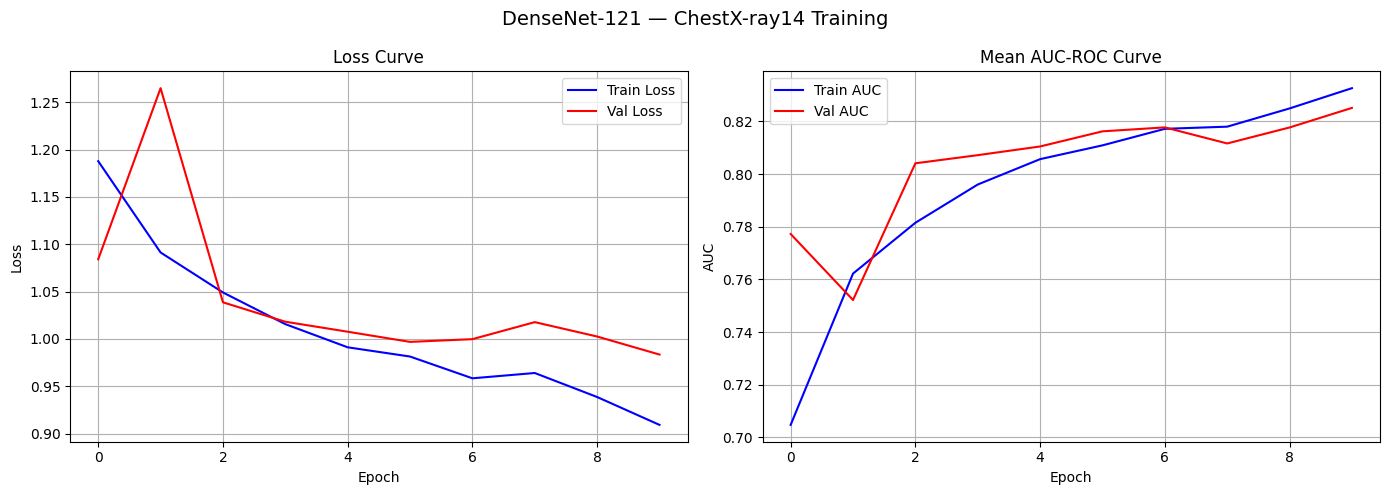

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='red')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_auc'], label='Train AUC', color='blue')
axes[1].plot(history['val_auc'],   label='Val AUC',   color='red')
axes[1].set_title('Mean AUC-ROC Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('DenseNet-121 — ChestX-ray14 Training', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

## 11. Test Set Evaluation — AUC per Class

Test Loss: 1.4004 | Test Mean AUC: 0.7988

Per-Class AUC-ROC:
  Atelectasis              : 0.7447
  Cardiomegaly             : 0.8662
  Effusion                 : 0.8140
  Infiltration             : 0.7003
  Mass                     : 0.7942
  Nodule                   : 0.7403
  Pneumonia                : 0.7081
  Pneumothorax             : 0.8433
  Consolidation            : 0.7342
  Edema                    : 0.8321
  Emphysema                : 0.8967
  Fibrosis                 : 0.8200
  Pleural_Thickening       : 0.7546
  Hernia                   : 0.9351


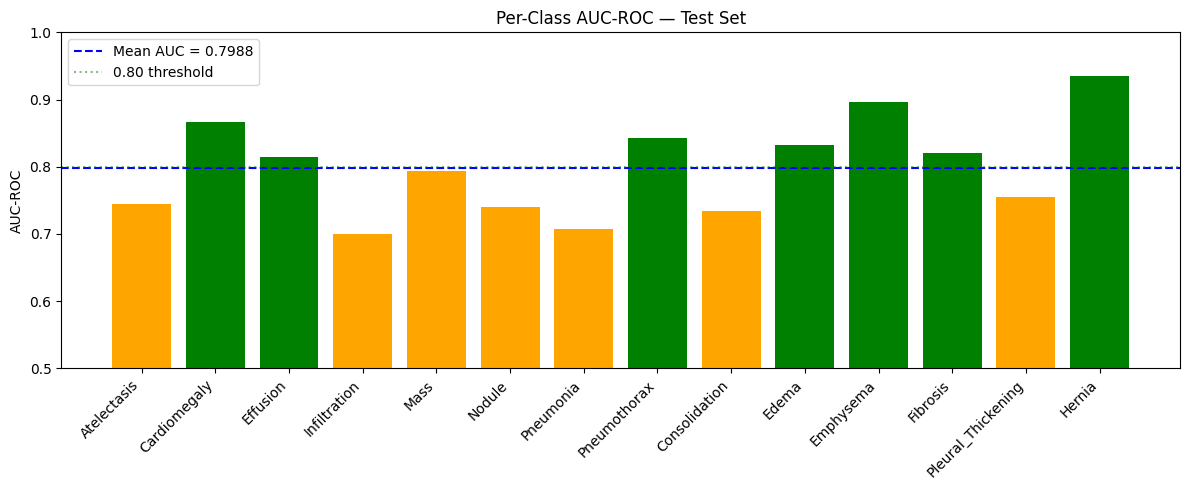

In [13]:
# Load best model
model.load_state_dict(torch.load('/kaggle/working/best_chest_model.pt', weights_only=True))
model.eval()

test_loss, test_auc, test_labels, test_outputs = evaluate(model, test_loader, criterion)
print(f'Test Loss: {test_loss:.4f} | Test Mean AUC: {test_auc:.4f}')

# Per-class AUC
print('\nPer-Class AUC-ROC:')
per_class_auc = {}
for i, label in enumerate(ALL_LABELS):
    if test_labels[:, i].sum() > 0:
        auc = roc_auc_score(test_labels[:, i], test_outputs[:, i])
        per_class_auc[label] = auc
        print(f'  {label:<25}: {auc:.4f}')

# Plot
plt.figure(figsize=(12, 5))
colors = ['green' if v >= 0.80 else 'orange' if v >= 0.70 else 'red'
          for v in per_class_auc.values()]
plt.bar(per_class_auc.keys(), per_class_auc.values(), color=colors)
plt.axhline(y=test_auc, color='blue', linestyle='--', label=f'Mean AUC = {test_auc:.4f}')
plt.axhline(y=0.80, color='green', linestyle=':', alpha=0.5, label='0.80 threshold')
plt.title('Per-Class AUC-ROC — Test Set')
plt.xticks(rotation=45, ha='right')
plt.ylabel('AUC-ROC')
plt.ylim(0.5, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/per_class_auc.png', dpi=150)
plt.show()

## 12. Save Model for Backend

In [18]:
!pip install onnxscript -q

In [19]:
# ── 1. Save .pt + .pth ───────────────────────────────────────────────
torch.save(model.state_dict(), '/kaggle/working/best_chest_model.pt')
print('✅ Saved: best_chest_model.pt')
torch.save(model.state_dict(), '/kaggle/working/best_chest_model.pth')
print('✅ Saved: best_chest_model.pth')

# ── 2. Export to ONNX ────────────────────────────────────────────────
dummy_input = torch.randn(1, 3, 224, 224).to(device)
torch.onnx.export(
    model,
    dummy_input,
    '/kaggle/working/chest_model.onnx',
    export_params=True,
    opset_version=11,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print('✅ Saved: chest_model.onnx')

# ── 3. Save metadata JSON ────────────────────────────────────────────
model_meta = {
    'model_name': 'DenseNet-121',
    'task': 'multi-label-classification',
    'dataset': 'NIH ChestX-ray14',
    'num_classes': 14,
    'classes': ALL_LABELS,
    'input_size': [224, 224],
    'input_channels': 3,
    'normalize_mean': [0.485, 0.456, 0.406],
    'normalize_std': [0.229, 0.224, 0.225],
    'output_activation': 'sigmoid',
    'best_val_auc': round(best_val_auc, 4),
    'test_mean_auc': round(test_auc, 4),
    'per_class_auc': {k: round(v, 4) for k, v in per_class_auc.items()}
}

with open('/kaggle/working/chest_model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)
print('✅ Saved: chest_model_meta.json')

print('\n📦 All files saved to /kaggle/working/')
print('Files:', os.listdir('/kaggle/working/'))

W0427 09:07:19.587000 166 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


✅ Saved: best_chest_model.pt
✅ Saved: best_chest_model.pth


W0427 09:07:20.128000 166 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0427 09:07:20.130000 166 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0427 09:07:20.132000 166 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0427 09:07:20.134000 166 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `DenseNet121_ChestXRay([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DenseNet121_ChestXRay([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).


[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Runtim

✅ Saved: chest_model.onnx
✅ Saved: chest_model_meta.json

📦 All files saved to /kaggle/working/
Files: ['chest_model.onnx', 'class_distribution.png', 'training_curves.png', 'best_chest_model.pt', 'best_chest_model.pth', 'chest_model_meta.json', 'chest_model.onnx.data', 'per_class_auc.png', '.virtual_documents']


## 13. Quick Inference Test

In [20]:
def predict_single_image(img_name, model, transform, labels, threshold=0.5):
    """Run inference on a single chest X-ray image."""
    model.eval()
    img_path = IMAGE_LOOKUP.get(img_name)
    if img_path is None:
        raise FileNotFoundError(f'Image not found: {img_name}')

    image  = Image.open(img_path).convert('RGB')
    tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = torch.sigmoid(model(tensor)).cpu().numpy()[0]

    results = {label: float(prob) for label, prob in zip(labels, output)}

    print('All probabilities:')
    for label, prob in sorted(results.items(), key=lambda x: x[1], reverse=True):
        bar  = '█' * int(prob * 20)
        flag = '⚠️' if prob >= threshold else '  '
        print(f'  {flag} {label:<25}: {prob:.3f} {bar}')

    return results


# Test on a random image from test set
sample_name = test_df.iloc[0]['Image Index']
print(f'Testing on: {sample_name}')
print(f'Ground truth: {test_df.iloc[0]["Finding Labels"]}\n')
results = predict_single_image(sample_name, model, val_transform, ALL_LABELS)

Testing on: 00000003_000.png
Ground truth: Hernia

All probabilities:
  ⚠️ Hernia                   : 1.000 ███████████████████
  ⚠️ Mass                     : 0.876 █████████████████
  ⚠️ Nodule                   : 0.753 ███████████████
  ⚠️ Atelectasis              : 0.600 ████████████
     Fibrosis                 : 0.432 ████████
     Infiltration             : 0.305 ██████
     Cardiomegaly             : 0.296 █████
     Pneumonia                : 0.223 ████
     Effusion                 : 0.183 ███
     Pleural_Thickening       : 0.165 ███
     Consolidation            : 0.114 ██
     Pneumothorax             : 0.093 █
     Emphysema                : 0.051 █
     Edema                    : 0.004 
